In [ ]:
from src.data_collection import get_multiple_seasons_shot_data, get_team_season_metrics, save_dataset

seasons = [
    "2010-11", "2011-12", "2012-13", "2013-14", "2014-15", "2015-16", "2016-17", "2017-18",
    "2018-19", "2019-20", "2020-21", "2021-22", "2022-23", "2023-24"
]

# shot_df = get_multiple_seasons_shot_data(seasons)
# save_dataset(shot_df, "data/shot_data.csv")

# metrics_df = get_team_season_metrics(seasons)
# save_dataset(metrics_df, "data/team_season_metrics.csv")

In [1]:
from src.data_collection import load_dataset, save_dataset
from src.data_cleaning import clean_shot_data, clean_team_metrics

raw_shots   = load_dataset("data/shot_data.csv")
raw_metrics = load_dataset("data/team_season_metrics.csv")

clean_shots   = clean_shot_data(raw_shots)
clean_metrics = clean_team_metrics(raw_metrics)

save_dataset(clean_shots,   "data/shot_data_clean.csv")
save_dataset(clean_metrics, "data/team_metrics_clean.csv")

print(clean_shots["zone_basic"].value_counts())
print(clean_shots["era"].value_counts())

Starting shot data cleaning pipeline...
Dropped 482 rows with missing coordinates
Dropped 5930 backcourt shots
Cleaning complete. Final shape: (2825763, 16)
Saved 2825763 rows to data/shot_data_clean.csv
Saved 420 rows to data/team_metrics_clean.csv
zone_basic
Restricted Area          891110
Above the Break 3        678028
Mid-Range                571860
In The Paint (Non-RA)    459957
Left Corner 3            116868
Right Corner 3           107940
Name: count, dtype: int64
era
Early (2013-17)     1379907
Mid (2017-21)        801558
Recent (2021-24)     644298
Name: count, dtype: int64


In [5]:
from src.analysis import (
    zone_distribution,
    three_point_rate_by_season,
    compare_eras,
    biggest_zone_shifts,
    rank_teams_by_three_point_adoption,
    correlate_three_pt_rate_with_wins,
    build_summary_table
)
from src.data_collection import load_dataset

shots   = load_dataset("data/shot_data_clean.csv")
metrics = load_dataset("data/team_metrics_clean.csv")

trend = three_point_rate_by_season(shots)
print(trend)

shifts = biggest_zone_shifts(shots)
print(shifts)

rankings = rank_teams_by_three_point_adoption(shots)
print(rankings.head(10))

corr_df = correlate_three_pt_rate_with_wins(shots, metrics)

summary = build_summary_table(shots)
print(summary)

     season  total_attempts  three_pt_attempts  three_pt_rate
0   2010-11          199292              43831      21.993356
1   2011-12          160901              36076      22.421240
2   2012-13          201159              48629      24.174409
3   2013-14          203682              52495      25.773019
4   2014-15          205123              54696      26.664977
5   2015-16          200320              56087      27.998702
6   2016-17          209430              65743      31.391396
7   2017-18          204181              68576      33.585887
8   2018-19          218992              78168      35.694455
9   2019-20          187711              71766      38.232176
10  2020-21          190674              74452      39.046750
11  2021-22          209217              82766      39.559883
12  2022-23          216814              83630      38.572232
13  2023-24          218267              85921      39.365090
              zone_basic  pct_first   pct_last     change
0      Above

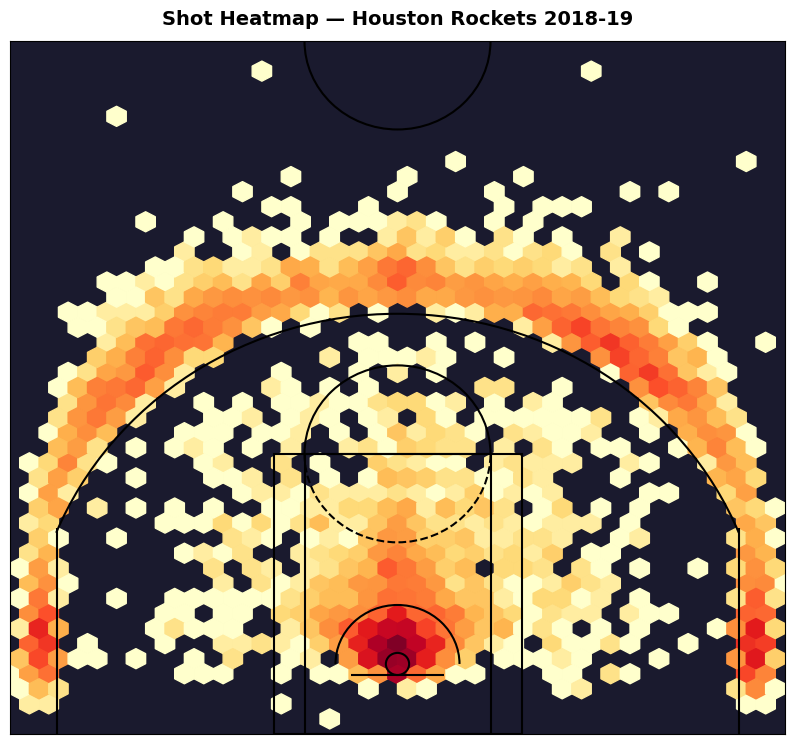

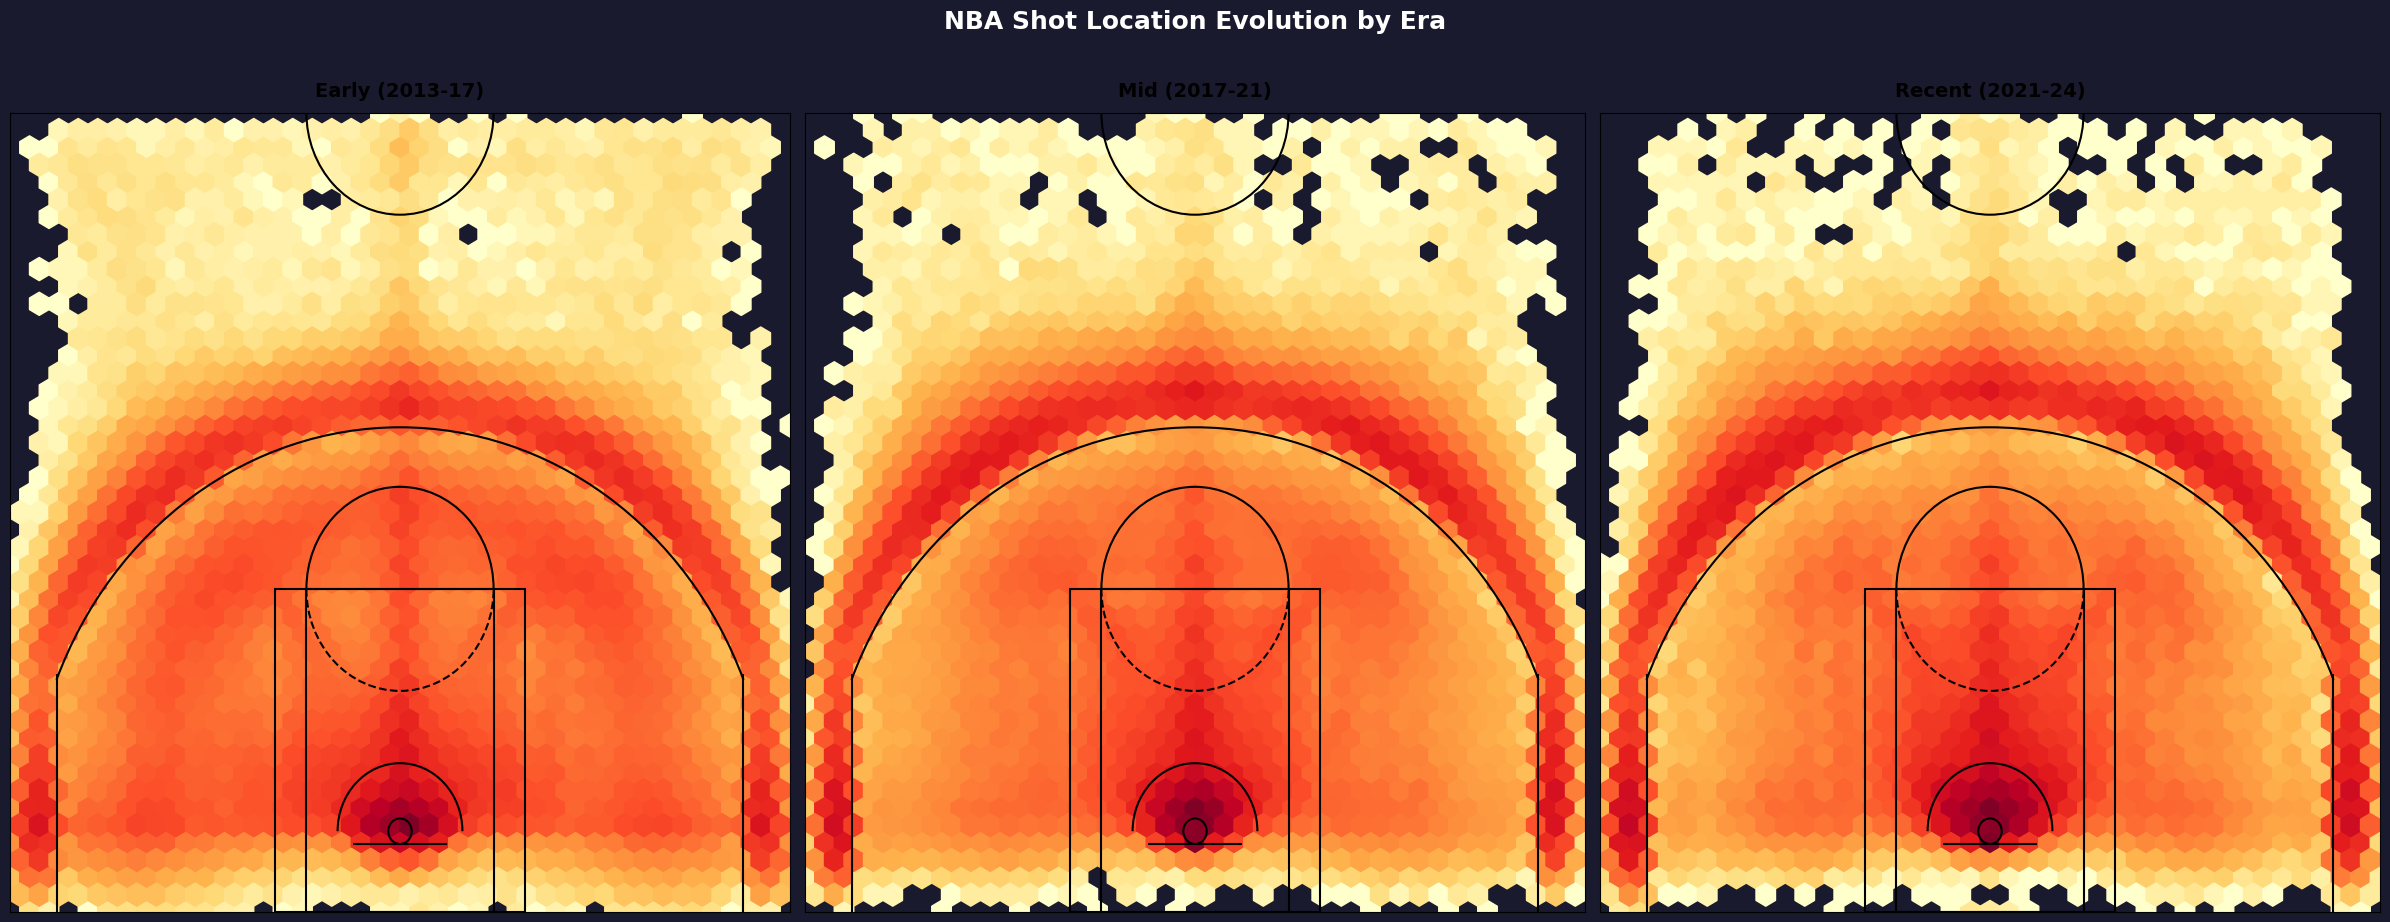

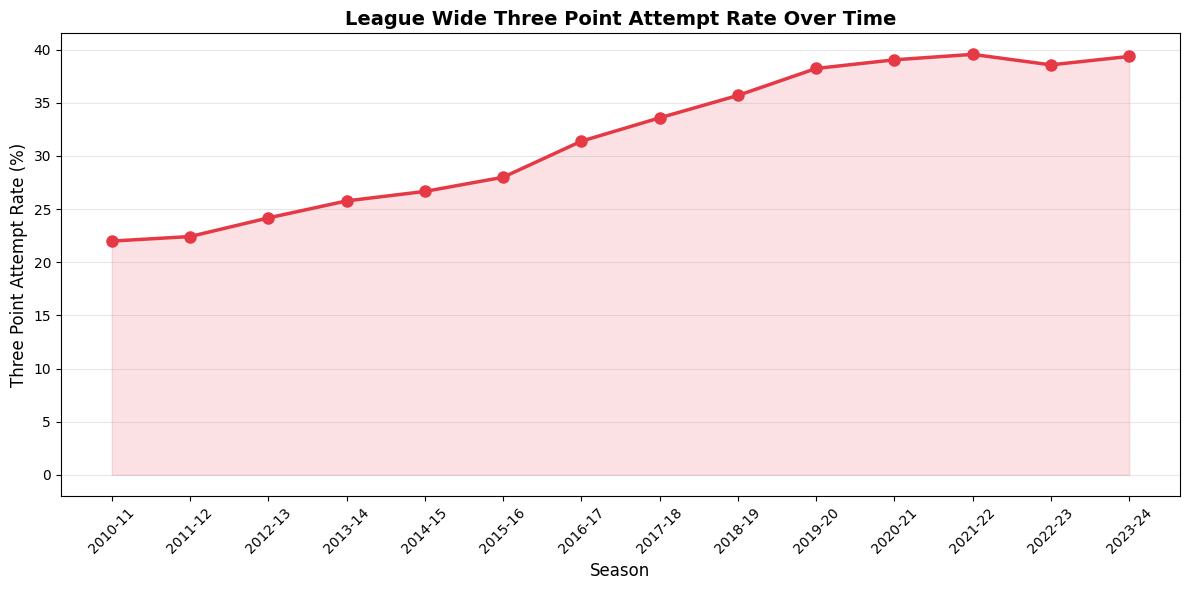

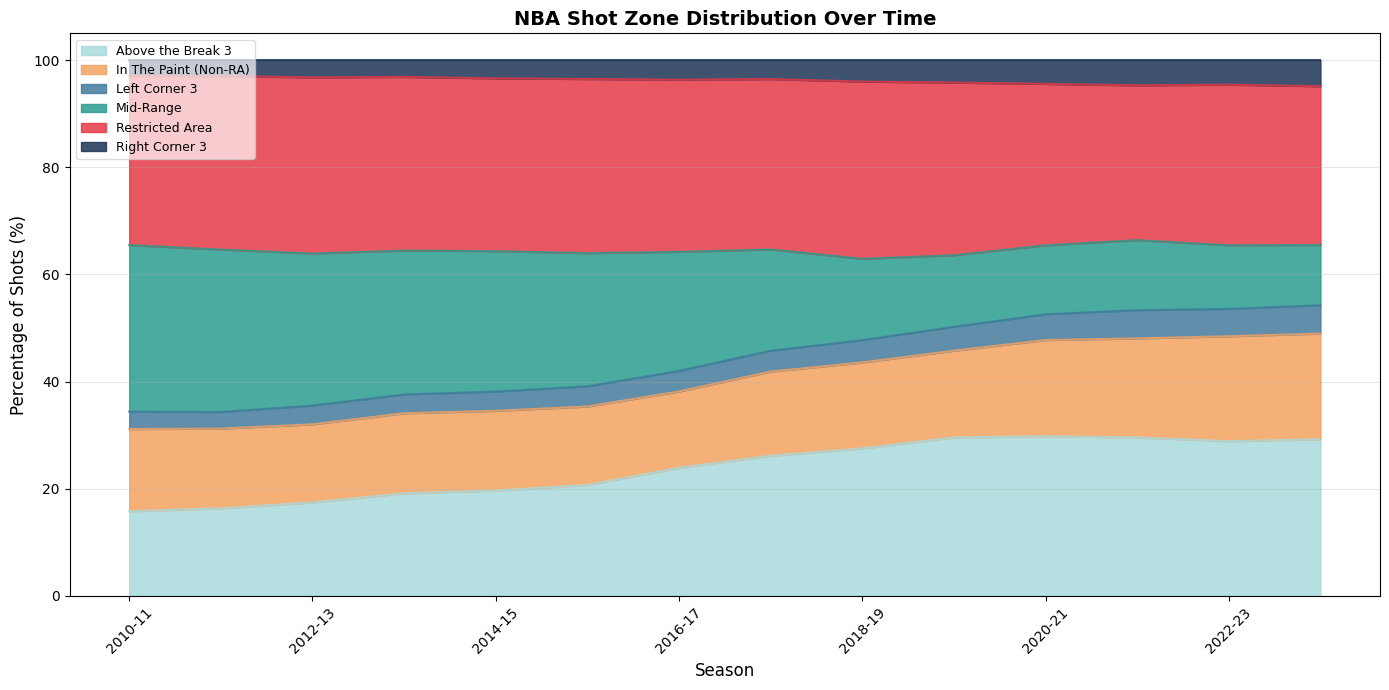

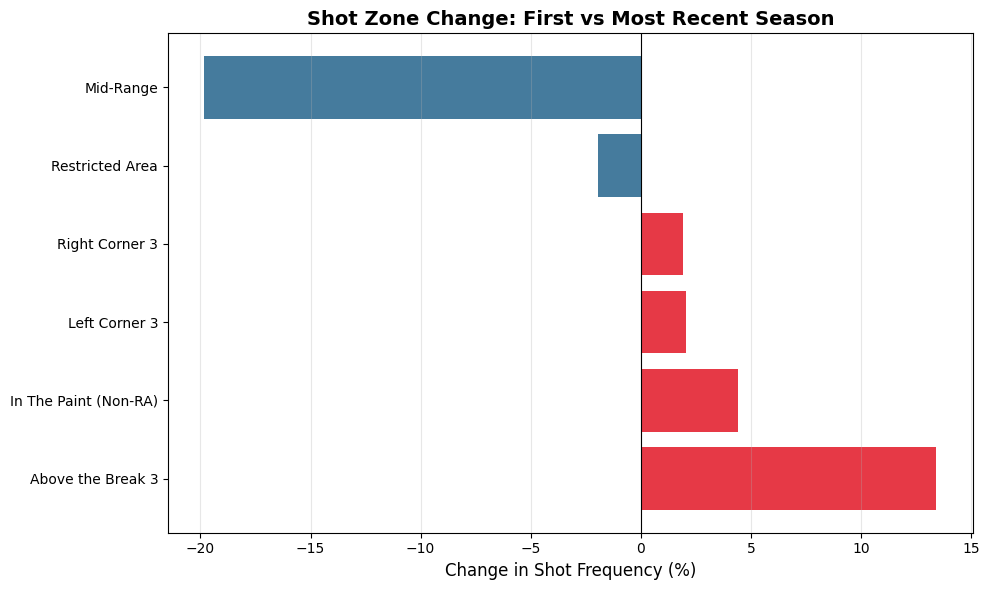

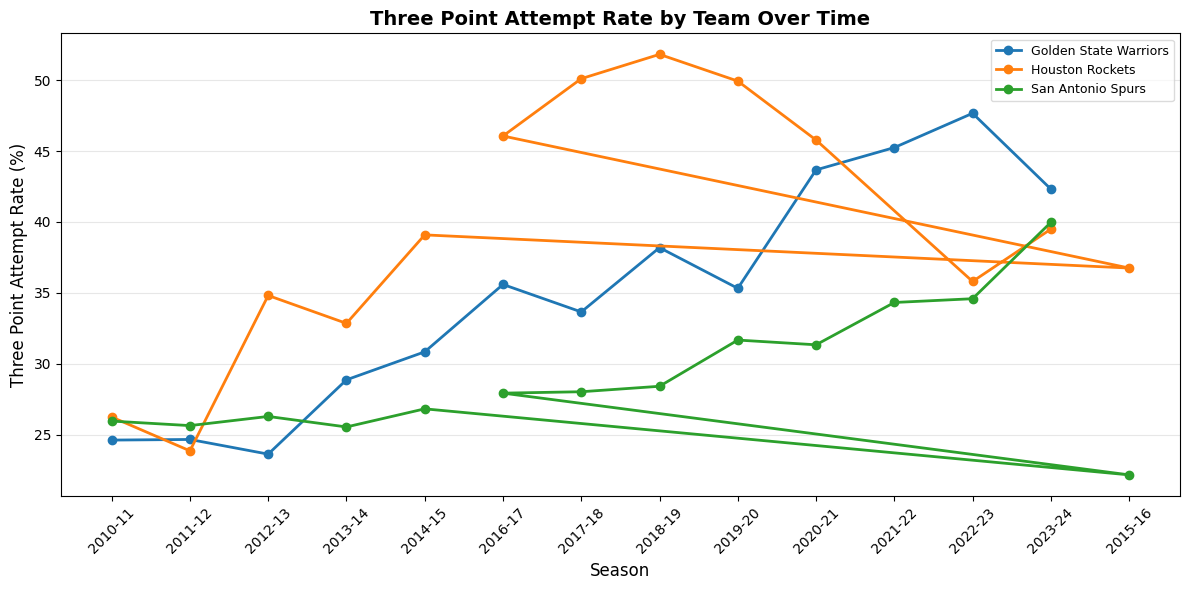

Correlation between three point rate and win pct: 0.142


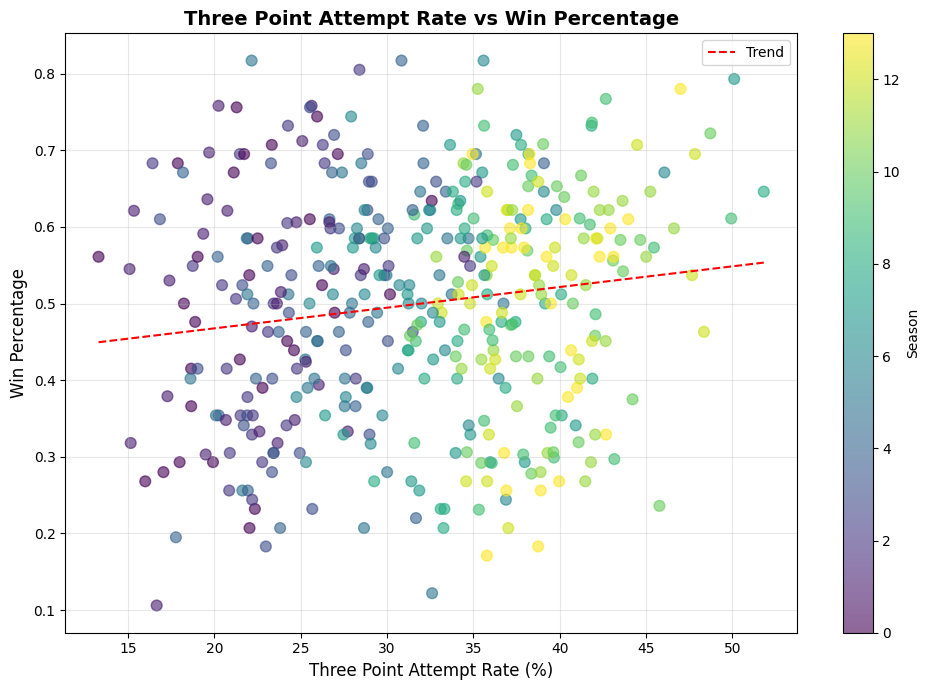

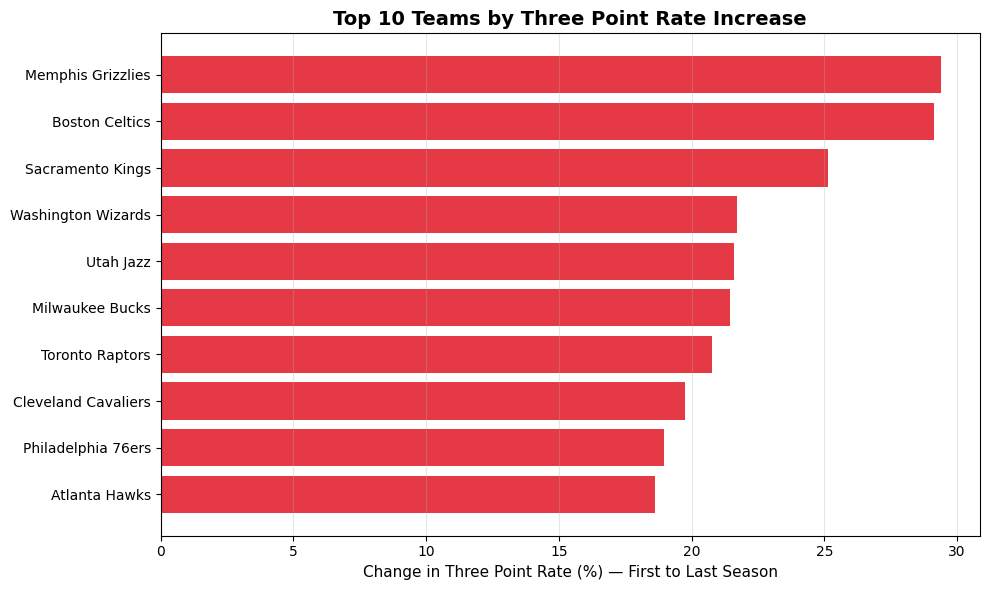

In [6]:
from src.visualization import (
    plot_court_heatmap,
    plot_era_heatmap_comparison,
    plot_three_point_trend,
    plot_zone_distribution_over_time,
    plot_zone_shift_bar,
    plot_team_three_point_trajectory,
    plot_three_pt_vs_wins,
    plot_top_three_point_adopters
)
from src.analysis import correlate_three_pt_rate_with_wins
from src.data_collection import load_dataset
import matplotlib.pyplot as plt

shots   = load_dataset("data/shot_data_clean.csv")
metrics = load_dataset("data/team_metrics_clean.csv")

# Court heatmap for one team
fig = plot_court_heatmap(shots, team="Houston Rockets", season="2018-19")
plt.show()

# Era comparison side by side
fig = plot_era_heatmap_comparison(shots)
plt.show()

# League wide three point trend
fig = plot_three_point_trend(shots)
plt.show()

# Stacked area chart
fig = plot_zone_distribution_over_time(shots)
plt.show()

# Which zones changed most
fig = plot_zone_shift_bar(shots)
plt.show()

# Team trajectories
fig = plot_team_three_point_trajectory(
    shots,
    teams=["Houston Rockets", "San Antonio Spurs", "Golden State Warriors"]
)
plt.show()

# Three point rate vs wins
corr_df = correlate_three_pt_rate_with_wins(shots, metrics)
fig = plot_three_pt_vs_wins(corr_df)
plt.show()

# Top adopters
fig = plot_top_three_point_adopters(shots)
plt.show()